# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [37]:
#! pip install mne

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

In [39]:
CONDITION   = "BLT"
SUBJECT_IDS = np.setdiff1d(np.arange(1,18,1), [1, 4, 14])
CHANNELS    = "all"                 # T7, T8, TP7, TP8
FREQ_BANDS  = "delta_beta"          # 0.5–30Hz

all_sub_data = {}
all_data_bc_list = []
all_trial_rows = []

BASELINE_TMIN = -0.200
BASELINE_TMAX =  0.000

for sub_id in SUBJECT_IDS:
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    n_trials, n_channels, n_times = data.shape

    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    baseline_std  = data[:, :, baseline_mask].std(axis=-1, keepdims=True)

    # 避免除0
    baseline_std[baseline_std == 0] = np.nan

    data_bc = (data - baseline_mean) / baseline_std   # z-score baseline corrected

    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_times": n_times,
    }

    all_data_bc_list.append(data_bc)

    for t in range(n_trials):
        all_trial_rows.append({
            "sub_id": sub_id,
            "trial_index": t + 1,
        })

    print(
        f"Loaded Subject {sub_id} | trials={n_trials}, "
        f"channels={n_channels}, times={n_times}"
    )

ref_sub = SUBJECT_IDS[0]
times = all_sub_data[ref_sub]["times"]
ch_names = all_sub_data[ref_sub]["ch_names"]
time_ms = times * 1000

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 2 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 3 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Loaded Subject 15 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 16 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 17 | trials=60, channels=32, times=1792


In [40]:
print(ch_names)

['AF7', 'FPZ', 'AF8', 'AF3', 'AF4', 'F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'POz', 'O1', 'Oz', 'O2']


## 2. Baseline Correction  (−200 ms to 0 ms, mean subtraction)

In [41]:
BASELINE_TMIN = -0.200   # seconds
BASELINE_TMAX =  0.000

all_sub_data = {}
all_data_bc_list = []

for sub_id in SUBJECT_IDS:
    # -------------------------
    # 1) load one subject
    # -------------------------
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    # -------------------------
    # 2) subject-specific baseline correction
    # -------------------------
    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)

    if baseline_mask.sum() == 0:
        raise ValueError(
            f"Subject {sub_id}: no baseline samples found in "
            f"[{BASELINE_TMIN}, {BASELINE_TMAX}] sec"
        )

    print(
        f"Subject {sub_id} baseline samples: {baseline_mask.sum()} "
        f"({times[baseline_mask][0]*1000:.0f} ms to {times[baseline_mask][-1]*1000:.0f} ms)"
    )

    # mean/std for each trial × channel, using this subject's own baseline
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)   # (trials, channels, 1)
    baseline_std  = data[:, :, baseline_mask].std(axis=-1, keepdims=True)    # (trials, channels, 1)

    # avoid divide-by-zero
    baseline_std[baseline_std == 0] = np.nan

    data_bc = (data - baseline_mean) / baseline_std   # (trials, channels, times)

    print(f"Subject {sub_id} baseline correction done — data_bc shape: {data_bc.shape}")

    # store
    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
    }

    all_data_bc_list.append(data_bc)

# -------------------------
# 3) concatenate all subjects after each was corrected separately
# -------------------------
all_data_bc = np.concatenate(all_data_bc_list, axis=0)   # (total_trials, n_channels, n_times)

print("All-subject concatenated data_bc shape:", all_data_bc.shape)

# channel-wise grand average
grand_avg_by_channel = np.nanmean(all_data_bc, axis=0)   # (n_channels, T)

# ROI average across channels
grand_avg_tactile = np.nanmean(grand_avg_by_channel, axis=0)   # (T,)

print("grand_avg_by_channel shape:", grand_avg_by_channel.shape)
print("grand_avg_tactile shape:", grand_avg_tactile.shape)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 2 baseline samples: 103 (-199 ms to 0 ms)
Subject 2 baseline correction done — data_bc shape: (60, 32, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 3 baseline samples: 103 (-199 ms to 0 ms)
Subject 3 baseline correction done — data_bc shape: (60, 32, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Subject 15 baseline samples: 103 (-199 ms to 0 ms)
Subject 15 baseline correction done — data_bc shape: (60, 32, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 16 baseline samples: 103 (-199 ms to 0 ms)
Subject 16 baseline correction done — data_bc shape: (60, 32, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 17 baseline samples: 103 (-199 ms to 0 ms)
Subject 17 baseline correction done — data_bc shape: (60, 32, 1792)
All-subject concatenated data_bc shape: (840, 32, 1792)
grand_avg_by_channel shape: (32, 1792)
grand_avg_tactile shape: (1792,)


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_peak_in_window(time_ms, signal, window_ms, polarity="pos"):
    """
    在给定时间窗内找 peak / trough

    Parameters
    ----------
    time_ms : array-like, shape [T]
    signal : array-like, shape [T]
    window_ms : [start_ms, end_ms]
    polarity : {"pos", "neg"}
        pos: 找最大值
        neg: 找最小值

    Returns
    -------
    out : dict
        {
            "peak_idx": int or None,
            "peak_time_ms": float or np.nan,
            "peak_amp": float or np.nan,
            "search_start_ms": float,
            "search_end_ms": float,
            "polarity": str,
        }
    """
    time_ms = np.asarray(time_ms, dtype=float)
    signal = np.asarray(signal, dtype=float)

    start_ms, end_ms = window_ms
    mask = (time_ms >= start_ms) & (time_ms <= end_ms)

    if not np.any(mask):
        return {
            "peak_idx": None,
            "peak_time_ms": np.nan,
            "peak_amp": np.nan,
            "search_start_ms": start_ms,
            "search_end_ms": end_ms,
            "polarity": polarity,
        }

    idx_local = np.where(mask)[0]
    seg = signal[idx_local]

    if polarity == "pos":
        best_local = np.nanargmax(seg)
    elif polarity == "neg":
        best_local = np.nanargmin(seg)
    else:
        raise ValueError("polarity must be 'pos' or 'neg'")

    peak_idx = idx_local[best_local]

    return {
        "peak_idx": int(peak_idx),
        "peak_time_ms": float(time_ms[peak_idx]),
        "peak_amp": float(signal[peak_idx]),
        "search_start_ms": float(start_ms),
        "search_end_ms": float(end_ms),
        "polarity": polarity,
    }


def _default_half_width_ms(peak_time_ms):
    """
    根据 peak latency 自动决定最终窗半宽
    """
    if peak_time_ms < 120:
        return 15.0
    elif peak_time_ms < 250:
        return 25.0
    else:
        return 40.0


def build_final_window_from_peak(
    peak_time_ms,
    half_width_ms=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    由 peak time 生成最终分析窗
    """
    if np.isnan(peak_time_ms):
        return [np.nan, np.nan]

    if half_width_ms is None:
        half_width_ms = _default_half_width_ms(peak_time_ms)

    tw = [peak_time_ms - half_width_ms, peak_time_ms + half_width_ms]

    if min_time_ms is not None:
        tw[0] = max(tw[0], min_time_ms)
    if max_time_ms is not None:
        tw[1] = min(tw[1], max_time_ms)

    return [float(tw[0]), float(tw[1])]


def detect_erp_windows_from_grand_avg(
    time_ms,
    grand_avg,
    search_windows,
    polarity_map=None,
    half_width_map=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    在 grand average 上自动检测 ERP 成分，并生成最终时间窗

    Parameters
    ----------
    time_ms : array-like, shape [T]
    grand_avg : array-like, shape [T]
    search_windows : dict
        例如:
        {
            "P50": [30, 80],
            "N1": [70, 140],
            "P2": [130, 220],
            "N2": [180, 300],
            "P3": [250, 450],
        }

    polarity_map : dict or None
        例如:
        {
            "P50": "pos",
            "N1": "neg",
            "P2": "pos",
            "N2": "neg",
            "P3": "pos",
        }
        如果不提供，默认全是 "pos"

    half_width_map : dict or None
        每个成分最终窗半宽（ms）
        例如:
        {
            "P50": 12,
            "N1": 15,
            "P2": 20,
            "N2": 25,
            "P3": 40,
        }
        不提供则自动按 peak latency 决定

    Returns
    -------
    res_df : pd.DataFrame
        index 为 component name
        columns:
            peak_idx
            peak_time_ms
            peak_amp
            search_start_ms
            search_end_ms
            polarity
            final_start_ms
            final_end_ms
            final_half_width_ms
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    if polarity_map is None:
        polarity_map = {k: "pos" for k in search_windows}

    rows = []
    for comp, tw in search_windows.items():
        polarity = polarity_map.get(comp, "pos")

        peak_info = _find_peak_in_window(
            time_ms=time_ms,
            signal=grand_avg,
            window_ms=tw,
            polarity=polarity,
        )

        peak_time = peak_info["peak_time_ms"]

        if half_width_map is not None and comp in half_width_map:
            half_width = float(half_width_map[comp])
        else:
            half_width = _default_half_width_ms(peak_time) if not np.isnan(peak_time) else np.nan

        final_tw = build_final_window_from_peak(
            peak_time_ms=peak_time,
            half_width_ms=half_width if not np.isnan(half_width) else None,
            min_time_ms=min_time_ms,
            max_time_ms=max_time_ms,
        )

        row = {
            "component": comp,
            **peak_info,
            "final_start_ms": final_tw[0],
            "final_end_ms": final_tw[1],
            "final_half_width_ms": half_width,
        }
        rows.append(row)

    res_df = pd.DataFrame(rows).set_index("component")
    return res_df


def plot_grand_avg_with_windows(
    time_ms,
    grand_avg,
    res_df,
    title="Grand Average ERP with Detected Windows",
    figsize=(10, 5),
):
    """
    画 grand average，并标注 peak 和 final windows
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    plt.figure(figsize=figsize)
    plt.plot(time_ms, grand_avg, linewidth=2, label="grand avg", color="black")
    plt.axvline(0, linestyle="--", alpha=0.6)

    y_min = np.nanmin(grand_avg)
    y_max = np.nanmax(grand_avg)
    y_span = y_max - y_min if y_max > y_min else 1.0

    for comp, row in res_df.iterrows():
        fs = row["final_start_ms"]
        fe = row["final_end_ms"]
        pt = row["peak_time_ms"]
        pa = row["peak_amp"]
        color = "orange" if row["polarity"] == "pos" else "cyan"

        if not np.isnan(fs) and not np.isnan(fe):
            plt.axvspan(fs, fe, alpha=0.15, color=color)

        if not np.isnan(pt) and not np.isnan(pa):
            plt.scatter([pt], [pa], s=60, color=color)
            plt.text(
                pt,
                pa + 0.03 * y_span,
                f"{comp}\n{pt:.1f} ms",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.xlim(-200,800)
    plt.ylim(-1.5,1.5)
    plt.xticks(np.arange(-200, 801, 50))
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [43]:
auditory_search = {
    "P50": [30, 100],
    "N1":  [80, 160],
    "P2":  [150, 250],
    "N2":  [180, 320],
    "P3":  [250, 500],
}

tactile_search = {
    "P50": [20, 70],
    "N1":  [50, 120],
    "P2":  [100, 200],
    "N2":  [130, 260],
    "P3":  [220, 420],
}



half_width_map= {
    "P50": 15,
    "N1":  25,
    "P2":  25,
    "N2":  25,
    "P3":  50,
}

tactile_polarity = {
    "P50": "pos",
    "N1":  "neg",
    "P2":  "pos",
    "N2":  "neg",
    "P3":  "pos",
}

auditory_polarity = {
    "P50": "pos",
    "N1":  "neg",
    "P2":  "pos",
    "N2":  "neg",
    "P3":  "pos",
}

           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50             267     21.484375 -0.004026             20.0           70.0   
N1              285     56.640625 -0.009501             50.0          120.0   
P2              321    126.953125 -0.001278            100.0          200.0   
N2              335    154.296875 -0.013532            130.0          260.0   
P3              369    220.703125 -0.003919            220.0          420.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50            pos        6.484375     36.484375                 15.0  
N1             neg       31.640625     81.640625                 25.0  
P2             pos      101.953125    151.953125                 25.0  
N2             neg      129.296875    179.296875                 25.0  
P3            

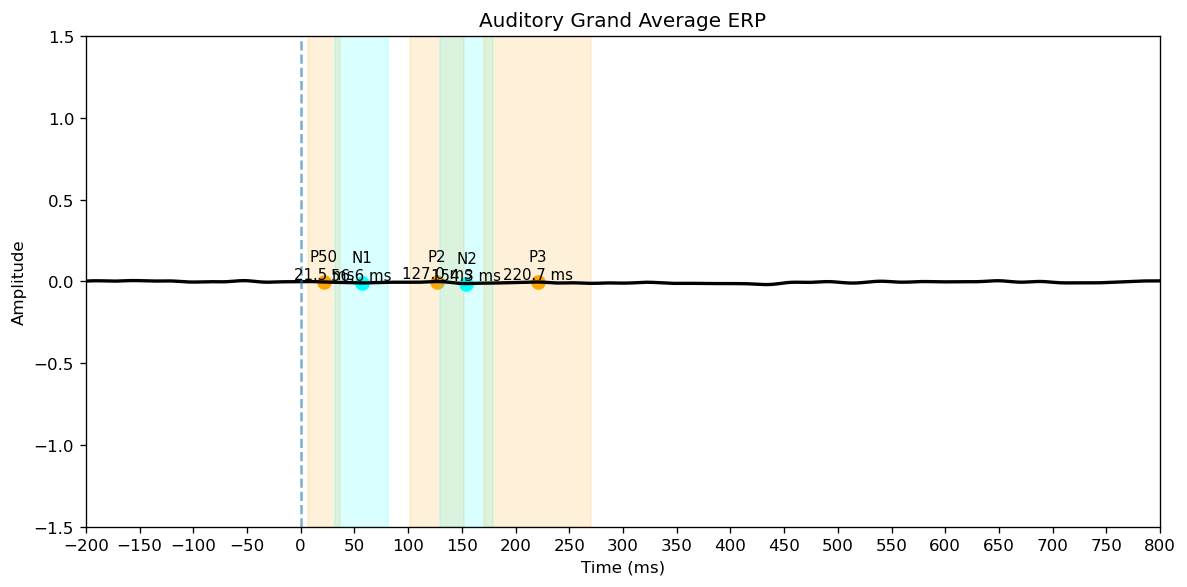

In [44]:
res_aud = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_tactile,
    search_windows=tactile_search,
    polarity_map=tactile_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print(res_aud)
plot_grand_avg_with_windows(
    time_ms=time_ms,
    grand_avg=grand_avg_tactile,
    res_df=res_aud,
    title="Auditory Grand Average ERP",
)

## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [45]:
import numpy as np
import pandas as pd

# =========================
# 1) read time_wind
# =========================

component_windows = {
    comp: {
        "tmin_s": row["final_start_ms"] / 1000.0,
        "tmax_s": row["final_end_ms"] / 1000.0,
        "polarity": row["polarity"],
    }
    for comp, row in res_aud.iterrows()
}

print("Detected windows from res_aud:")
for comp, info in component_windows.items():
    print(
        f"  {comp}: {info['tmin_s']*1000:.1f}–{info['tmax_s']*1000:.1f} ms "
        f"(polarity={info['polarity']})"
    )

all_features_df_list = []
all_roi_features_df_list = [] 

for sub_id in SUBJECT_IDS:
    sub_pack = all_sub_data[sub_id]
    data_bc = sub_pack["data_bc"]          # (n_trials, n_channels, n_times)
    times   = sub_pack["times"]
    ch_names = sub_pack["ch_names"]

    n_trials, n_channels, _ = data_bc.shape

    # =========================
    # 1) build window masks
    # =========================
    window_masks = {}
    for comp, info in component_windows.items():
        mask = (times >= info["tmin_s"]) & (times <= info["tmax_s"])
        window_masks[comp] = mask

    # =========================
    # 2) extract mean amp
    # =========================
    feat_mean = {}
    for comp, mask in window_masks.items():
        # (n_trials, n_channels)
        feat_mean[comp] = np.nanmean(data_bc[:, :, mask], axis=-1)

    # =========================
    # 3) extract peak amp / latency
    # =========================
    feat_peak_amp = {}
    feat_peak_lat_ms = {}

    for comp, mask in window_masks.items():
        polarity = component_windows[comp]["polarity"]
        times_win = times[mask]
        win_data = data_bc[:, :, mask]   # (n_trials, n_channels, samples)

        if polarity == "pos":
            peak_ix = np.nanargmax(win_data, axis=-1)
        elif polarity == "neg":
            peak_ix = np.nanargmin(win_data, axis=-1)
        else:
            raise ValueError(f"Unknown polarity for {comp}: {polarity}")

        peak_amp = np.take_along_axis(
            win_data,
            peak_ix[..., None],
            axis=-1
        ).squeeze(-1)

        peak_lat_ms = times_win[peak_ix] * 1000.0

        feat_peak_amp[comp] = peak_amp
        feat_peak_lat_ms[comp] = peak_lat_ms

    # =========================
    # 4) trial × channel features_df
    # =========================
    rows = []
    for t in range(n_trials):
        for c, ch in enumerate(ch_names):
            row = {
                "sub_id": sub_id,
                "trial_index": t + 1,
                "channel": ch,
            }

            for comp in component_windows.keys():
                row[f"{comp}_mean_amp"] = feat_mean[comp][t, c]
                row[f"{comp}_peak_amp"] = feat_peak_amp[comp][t, c]
                row[f"{comp}_peak_lat_ms"] = feat_peak_lat_ms[comp][t, c]

            rows.append(row)

    features_df_sub = pd.DataFrame(rows)
    all_features_df_list.append(features_df_sub)

    # =========================
    # 5) ROI average across channels
    # =========================
    roi_rows = []
    for t in range(n_trials):
        row = {
            "sub_id": sub_id,
            "trial_index": t + 1,
        }

        for comp in component_windows.keys():
            row[f"{comp}_mean_amp_roi"] = np.nanmean(feat_mean[comp][t])
            row[f"{comp}_peak_amp_roi"] = np.nanmean(feat_peak_amp[comp][t])
            row[f"{comp}_peak_lat_ms_roi"] = np.nanmean(feat_peak_lat_ms[comp][t])

        roi_rows.append(row)

    roi_features_df_sub = pd.DataFrame(roi_rows)
    all_roi_features_df_list.append(roi_features_df_sub)

erp_features_all_df = pd.concat(all_features_df_list, ignore_index=True)
erp_roi_features_all_df = pd.concat(all_roi_features_df_list, ignore_index=True)

print("Per-channel feature df:")
display(erp_features_all_df.head())

print("ROI feature df:")
display(erp_roi_features_all_df.head())

Detected windows from res_aud:
  P50: 6.5–36.5 ms (polarity=pos)
  N1: 31.6–81.6 ms (polarity=neg)
  P2: 102.0–152.0 ms (polarity=pos)
  N2: 129.3–179.3 ms (polarity=neg)
  P3: 170.7–270.7 ms (polarity=pos)
Per-channel feature df:


,sub_id,trial_index,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N1_mean_amp,N1_peak_amp,N1_peak_lat_ms,P2_mean_amp,P2_peak_amp,P2_peak_lat_ms,N2_mean_amp,N2_peak_amp,N2_peak_lat_ms,P3_mean_amp,P3_peak_amp,P3_peak_lat_ms
0,2,1,AF7,-1.129444,-0.432642,35.15625,-0.159155,-0.955202,80.078125,-0.330485,0.028666,142.578125,-0.618927,-1.413652,171.875000,-0.308256,0.655136,244.140625
1,2,1,FPZ,-1.259666,-0.496674,35.15625,-0.535928,-1.392205,80.078125,-0.736041,-0.088821,146.484375,-1.020096,-2.057879,169.921875,-0.565149,0.493074,251.953125
2,2,1,AF8,-1.384107,-0.650534,35.15625,-0.302913,-1.265417,80.078125,-0.443132,0.052172,144.531250,-0.681547,-1.448403,167.968750,-0.376971,0.623886,248.046875
3,2,1,AF3,-1.115151,-0.432417,35.15625,-0.511363,-1.535203,80.078125,-1.289448,-0.534521,148.437500,-1.390215,-2.553921,175.781250,-0.992429,0.161184,257.812500
4,2,1,AF4,-1.631837,-0.846502,35.15625,-0.618753,-1.685521,80.078125,-1.316551,-0.044889,146.484375,-1.356178,-2.825443,169.921875,-0.910120,0.250927,257.812500


ROI feature df:


,sub_id,trial_index,P50_mean_amp_roi,P50_peak_amp_roi,P50_peak_lat_ms_roi,N1_mean_amp_roi,N1_peak_amp_roi,N1_peak_lat_ms_roi,P2_mean_amp_roi,P2_peak_amp_roi,P2_peak_lat_ms_roi,N2_mean_amp_roi,N2_peak_amp_roi,N2_peak_lat_ms_roi,P3_mean_amp_roi,P3_peak_amp_roi,P3_peak_lat_ms_roi
0,2,1,-0.146656,0.427339,21.301270,-0.186509,-1.033581,63.171387,-0.255285,0.802179,126.037598,-0.192221,-1.304796,153.503418,-0.173849,1.223666,215.270996
1,2,2,-0.061291,0.739932,22.277832,0.077646,-0.971203,59.020996,-0.013920,1.401229,129.821777,-0.114793,-1.516238,149.536133,-0.078965,1.729917,221.130371
2,2,3,0.087820,0.752420,22.094727,0.147336,-0.790608,55.908203,0.041247,0.875957,124.755859,0.018042,-0.735048,158.142090,0.081009,1.370752,218.383789
3,2,4,0.049828,0.791080,21.850586,0.055031,-1.134272,57.495117,0.087015,0.968843,129.638672,-0.164427,-1.108840,156.982422,-0.103229,1.579408,207.946777
4,2,5,0.010123,0.898748,24.108887,0.036218,-1.013188,56.213379,0.152779,1.805773,122.863770,0.187839,-1.237822,151.367188,0.166947,1.848342,219.970703


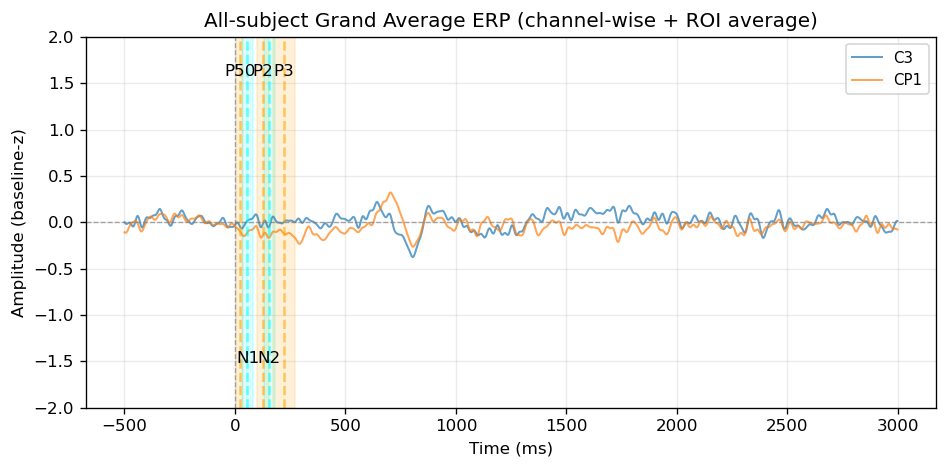

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))

for c, ch in enumerate(ch_names):
    if ch not in ["C3", "CP1"]:
        continue
    ax.plot(
        time_ms,
        grand_avg_by_channel[c],
        linewidth=1.2,
        alpha=0.7,
        label=ch
    )

# ax.plot(
#     time_ms,
#     grand_avg_tactile,
#     color="black",
#     linewidth=3,
#     label="ROI average"
# )

min_amp = np.nanmin(grand_avg_tactile)
max_amp = np.nanmax(grand_avg_tactile)

for comp, row in res_aud.iterrows():
    color = "orange" if row["polarity"] == "pos" else "cyan"
    text_pos_y = -1.55 if row["polarity"] == "neg" else 1.55
    ax.axvspan(
        row["final_start_ms"],
        row["final_end_ms"],
        alpha=0.15,
        color=color
    )
    ax.axvline(row["peak_time_ms"], linestyle="--", alpha=0.6, color=color)
    
    ax.text(
        row["peak_time_ms"],
        text_pos_y,
        comp,
        fontsize=10,
        ha="center",
        va="bottom"
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_title("All-subject Grand Average ERP (channel-wise + ROI average)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (baseline-z)")
# ax.set_xlim(-200,800)
# ax.set_xticks(np.arange(-200, 801, 50))
ax.set_ylim(-2, 2)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

In [47]:
# ROLLING_WINDOW = 10

# for sub_id in SUBJECT_IDS:
#     roi_features_df = erp_roi_features_all_df.query("sub_id == @sub_id").copy()
#     trial_idx = roi_features_df["trial_index"].values

#     windows = []
#     for comp in component_windows.keys():
#         windows.append((
#             f"{comp} mean amp",
#             roi_features_df[f"{comp}_mean_amp_roi"].values,
#             "royalblue",
#             "Mean amplitude (a.u.)"
#         ))
#         windows.append((
#             f"{comp} peak amp",
#             roi_features_df[f"{comp}_peak_amp_roi"].values,
#             "purple",
#             "Peak amplitude (a.u.)"
#         ))
#         windows.append((
#             f"{comp} peak latency",
#             roi_features_df[f"{comp}_peak_lat_ms_roi"].values,
#             "brown",
#             "Latency (ms)"
#         ))

#     n_plots = len(windows)
#     fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots), sharex=True)

#     if n_plots == 1:
#         axes = [axes]

#     for ax, (label, values, color, ylab) in zip(axes, windows):
#         ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label="Trial value")
#         ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

#         rolling = pd.Series(values).rolling(
#             window=ROLLING_WINDOW,
#             center=True,
#             min_periods=1
#         ).mean()

#         ax.plot(
#             trial_idx,
#             rolling,
#             color=color,
#             linewidth=2.5,
#             zorder=3,
#             label=f"Rolling mean (w={ROLLING_WINDOW})"
#         )

#         if "latency" not in label.lower():
#             ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

#         ax.set_ylabel(ylab, fontsize=10)
#         ax.set_title(f"Subject {sub_id} — ROI average — {label}", fontsize=10, fontweight="bold")
#         ax.legend(loc="upper right", fontsize=8)
#         ax.grid(True, alpha=0.25)

#     axes[-1].set_xlabel("Trial index", fontsize=11)

#     fig.suptitle(
#         f"{CONDITION} Protocol — Subject {sub_id}\nTrial-by-Trial Neural Dynamics",
#         fontsize=12,
#         fontweight="bold"
#     )

#     fig.tight_layout()
#     plt.show()

In [48]:
ROLLING_WINDOW = 5

REGIONS_DICT = {
    'BLA': {
        'T':  ['T7', 'T8'],
        'TP': ['TP7', 'TP8'],
    },

    'BLT': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
    },

    'CISI': {
        'T':  ['T7', 'T8'],
        'TP': ['TP7', 'TP8'],
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
    },

    'VISI': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
        'F':  ['F3', 'F4'],
        'FC': ['FC1', 'FC2', 'FC5', 'FC6'],
    },

    'RS': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
        'P':  ['P1', 'P2', 'P5', 'P6'],
    },
}


# =========================================================
# 0) 检查 CONDITION
# =========================================================
regions_of_interest = REGIONS_DICT.get(CONDITION, {})
if len(regions_of_interest) == 0:
    raise ValueError(f"No regions found for CONDITION={CONDITION}")

print(f"CONDITION = {CONDITION}")
print("Subregions:", list(regions_of_interest.keys()))


# =========================================================
# 1) 自动收集 component feature 列
# =========================================================
feature_cols = []
for comp in component_windows.keys():
    feature_cols.extend([
        f"{comp}_mean_amp",
        f"{comp}_peak_amp",
        f"{comp}_peak_lat_ms",
    ])

missing_cols = [col for col in feature_cols if col not in erp_features_all_df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing feature columns in erp_features_all_df: {missing_cols}")


# =========================================================
# 2) 按 subregion 分开计算
# =========================================================
all_region_group_roll_df = []
all_region_subject_roll_df = []
all_region_subject_feature_df = []

for region_name, roi_channels in regions_of_interest.items():
    print(f"\nProcessing region = {region_name}, channels = {roi_channels}")

    # -----------------------------------------------------
    # 2.1) 先筛这个 subregion 的 channel
    # -----------------------------------------------------
    df_roi = erp_features_all_df[
        erp_features_all_df["channel"].isin(roi_channels)
    ].copy()

    if len(df_roi) == 0:
        print(f"  Skipped: no data found for region {region_name}")
        continue

    # -----------------------------------------------------
    # 2.2) 按 sub_id + trial_index 聚合 ROI 内多个电极
    # -----------------------------------------------------
    agg_dict = {col: "mean" for col in feature_cols}

    erp_region_features_df = (
        df_roi
        .groupby(["sub_id", "trial_index"], observed=True, as_index=False)
        .agg(agg_dict)
        .sort_values(["sub_id", "trial_index"])
        .reset_index(drop=True)
    )

    erp_region_features_df["condition"] = CONDITION
    erp_region_features_df["region"] = region_name

    all_region_subject_feature_df.append(erp_region_features_df)

    # -----------------------------------------------------
    # 2.3) 每个被试内部按 trial 做 rolling
    # -----------------------------------------------------
    region_roll_list = []

    for sub_id in erp_region_features_df["sub_id"].unique():
        df_sub = erp_region_features_df.query("sub_id == @sub_id").copy()
        if len(df_sub) == 0:
            continue

        df_sub = df_sub.sort_values("trial_index").reset_index(drop=True)

        for comp in component_windows.keys():
            for suffix in ["mean_amp", "peak_amp", "peak_lat_ms"]:
                col = f"{comp}_{suffix}"
                roll_col = f"{col}_roll"
                df_sub[roll_col] = df_sub[col].rolling(
                    window=ROLLING_WINDOW,
                    center=True,
                    min_periods=1
                ).mean()

        df_sub["condition"] = CONDITION
        df_sub["region"] = region_name

        region_roll_list.append(df_sub)

    if len(region_roll_list) == 0:
        print(f"  Skipped: no rolling result for region {region_name}")
        continue

    erp_region_roll_df = pd.concat(region_roll_list, ignore_index=True)
    all_region_subject_roll_df.append(erp_region_roll_df)

    # -----------------------------------------------------
    # 2.4) across-subject grand average
    # -----------------------------------------------------
    group_rows = []

    for trial_index, df_trial in erp_region_roll_df.groupby("trial_index", observed=True):
        row = {
            "trial_index": trial_index,
            "condition": CONDITION,
            "region": region_name,
        }

        for comp in component_windows.keys():
            for suffix in ["mean_amp", "peak_amp", "peak_lat_ms"]:
                roll_col = f"{comp}_{suffix}_roll"
                row[f"{roll_col}_mean"] = df_trial[roll_col].mean()
                row[f"{roll_col}_sem"] = df_trial[roll_col].sem()

        group_rows.append(row)

    erp_region_group_roll_df = (
        pd.DataFrame(group_rows)
        .sort_values("trial_index")
        .reset_index(drop=True)
    )

    all_region_group_roll_df.append(erp_region_group_roll_df)


# =========================================================
# 3) 合并所有 subregion 的结果
# =========================================================
if len(all_region_subject_feature_df) > 0:
    erp_roi_features_df = pd.concat(all_region_subject_feature_df, ignore_index=True)
else:
    erp_roi_features_df = pd.DataFrame()

if len(all_region_subject_roll_df) > 0:
    erp_roi_roll_df = pd.concat(all_region_subject_roll_df, ignore_index=True)
else:
    erp_roi_roll_df = pd.DataFrame()

if len(all_region_group_roll_df) > 0:
    erp_roi_group_roll_df = pd.concat(all_region_group_roll_df, ignore_index=True)
    erp_roi_group_roll_df = erp_roi_group_roll_df.sort_values(
        ["region", "trial_index"]
    ).reset_index(drop=True)
else:
    erp_roi_group_roll_df = pd.DataFrame()


# =========================================================
# 4) display
# =========================================================
print("\n[Per-subject region-aggregated features]")
display(erp_roi_features_df.head())

print("\n[Per-subject rolling features]")
display(erp_roi_roll_df.head())

print("\n[Grand average rolling features]")
display(erp_roi_group_roll_df.head())

CONDITION = BLT
Subregions: ['C', 'CP']

Processing region = C, channels = ['C3', 'C4']

Processing region = CP, channels = ['CP1', 'CP2']

[Per-subject region-aggregated features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N1_mean_amp,N1_peak_amp,N1_peak_lat_ms,P2_mean_amp,P2_peak_amp,P2_peak_lat_ms,N2_mean_amp,N2_peak_amp,N2_peak_lat_ms,P3_mean_amp,P3_peak_amp,P3_peak_lat_ms,condition,region
0,2,1,-0.929072,-0.515435,14.648438,-1.064929,-1.895756,52.734375,-1.141910,-0.124268,123.046875,-0.724744,-1.994480,148.437500,-0.921617,1.210488,180.664062,BLT,C
1,2,2,-0.989198,-0.187020,17.578125,0.172429,-1.542959,36.132812,1.071746,1.967579,133.789062,1.073373,0.299493,156.250000,1.061476,2.613270,213.867188,BLT,C
2,2,3,0.912379,1.956540,21.484375,0.947194,0.159650,51.757812,0.565928,1.461013,103.515625,0.701641,0.065787,140.625000,0.818124,1.942396,189.453125,BLT,C
3,2,4,-0.232313,0.153355,15.625000,0.411682,-0.882309,38.085938,0.883945,1.808528,116.210938,0.008475,-1.086509,166.015625,-1.119102,1.076278,227.539062,BLT,C
4,2,5,0.254329,0.385565,15.625000,-0.280110,-1.009779,69.335938,0.485125,2.474185,140.625000,0.776093,-1.224636,164.062500,0.372961,2.227874,220.703125,BLT,C



[Per-subject rolling features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N1_mean_amp,N1_peak_amp,N1_peak_lat_ms,P2_mean_amp,P2_peak_amp,...,N1_peak_lat_ms_roll,P2_mean_amp_roll,P2_peak_amp_roll,P2_peak_lat_ms_roll,N2_mean_amp_roll,N2_peak_amp_roll,N2_peak_lat_ms_roll,P3_mean_amp_roll,P3_peak_amp_roll,P3_peak_lat_ms_roll
0,2,1,-0.929072,-0.515435,14.648438,-1.064929,-1.895756,52.734375,-1.141910,-0.124268,...,46.875000,0.165255,1.101441,120.117188,0.350090,-0.543067,148.437500,0.319328,1.922051,194.661458
1,2,2,-0.989198,-0.187020,17.578125,0.172429,-1.542959,36.132812,1.071746,1.967579,...,44.677734,0.344927,1.278213,119.140625,0.264686,-0.678927,152.832031,-0.040280,1.710608,202.880859
2,2,3,0.912379,1.956540,21.484375,0.947194,0.159650,51.757812,0.565928,1.461013,...,49.609375,0.372967,1.517407,123.437500,0.366967,-0.788069,155.078125,0.042368,1.814061,206.445312
3,2,4,-0.232313,0.153355,15.625000,0.411682,-0.882309,38.085938,0.883945,1.808528,...,53.125000,0.797735,1.948957,121.875000,0.570420,-0.485977,157.421875,0.388203,1.882233,219.726562
4,2,5,0.254329,0.385565,15.625000,-0.280110,-1.009779,69.335938,0.485125,2.474185,...,59.765625,0.143114,1.322280,116.796875,-0.027963,-1.177574,154.687500,0.080435,1.444484,219.140625



[Grand average rolling features]


,trial_index,condition,region,P50_mean_amp_roll_mean,P50_mean_amp_roll_sem,P50_peak_amp_roll_mean,P50_peak_amp_roll_sem,P50_peak_lat_ms_roll_mean,P50_peak_lat_ms_roll_sem,N1_mean_amp_roll_mean,...,N2_peak_amp_roll_mean,N2_peak_amp_roll_sem,N2_peak_lat_ms_roll_mean,N2_peak_lat_ms_roll_sem,P3_mean_amp_roll_mean,P3_mean_amp_roll_sem,P3_peak_amp_roll_mean,P3_peak_amp_roll_sem,P3_peak_lat_ms_roll_mean,P3_peak_lat_ms_roll_sem
0,1,BLT,C,-0.067269,0.064519,0.869089,0.105941,20.321801,1.182437,-0.097591,...,-1.343496,0.099555,155.482701,1.985236,-0.213452,0.108359,1.331798,0.154928,223.981585,3.941928
1,2,BLT,C,-0.102174,0.064099,0.777894,0.092072,21.048410,0.943881,-0.110748,...,-1.436224,0.120403,156.389509,1.421895,-0.304997,0.114572,1.283096,0.161566,222.708566,3.692228
2,3,BLT,C,-0.182360,0.068432,0.677460,0.085751,21.205357,1.004017,-0.170109,...,-1.454253,0.103492,156.696429,1.171773,-0.293922,0.114068,1.296652,0.165367,223.451451,3.079698
3,4,BLT,C,-0.186669,0.085424,0.704214,0.088386,22.181920,0.947524,-0.087424,...,-1.368537,0.123075,155.970982,1.189576,-0.211009,0.111751,1.393206,0.136687,223.423549,2.729731
4,5,BLT,C,-0.153339,0.096497,0.732992,0.098375,23.284040,0.918651,-0.085714,...,-1.424182,0.126329,155.803571,1.034192,-0.197526,0.127154,1.438877,0.146561,221.428571,1.868378


In [49]:
import numpy as np
import matplotlib.pyplot as plt


def plot_group_trial_dynamics(
    erp_roi_group_roll_df,
    component_windows,
    CONDITION=None,
    group_col="region",                  # 你现在应该用 "region"
    b_plot_channel_seperate=True,
    feature_specs=None,
    comp_colors=None,
    linestyle_map=None,
    figsize_per_row=(8, 3),
):
    """
    Plot grand-average rolling ERP features.

    Parameters
    ----------
    erp_roi_group_roll_df : pd.DataFrame
        Grand average dataframe. Must contain:
        - trial_index
        - group_col (e.g. region)
        - columns like P50_mean_amp_roll_mean, P50_mean_amp_roll_sem, ...

    component_windows : dict
        Component definition dict, only keys are used for plotting order.

    CONDITION : str or None
        Used in figure title.

    group_col : str
        Grouping column. Default: "region".

    b_plot_channel_seperate : bool
        If True: one subplot per group (region/channel).
        If False: overlay all groups in one subplot, use linestyle to distinguish groups.

    feature_specs : list of tuples or None
        Each tuple:
        (mean_suffix, sem_suffix, y_label, title_text)

    comp_colors : dict or None
        Mapping {component: color}

    linestyle_map : dict or None
        Mapping {group_name: linestyle}
    """

    if feature_specs is None:
        feature_specs = [
            ("mean_amp_roll_mean",   "mean_amp_roll_sem",   "Mean amplitude (a.u.)", "Mean amplitude"),
            ("peak_amp_roll_mean",   "peak_amp_roll_sem",   "Peak amplitude (a.u.)", "Peak amplitude"),
            ("peak_lat_ms_roll_mean","peak_lat_ms_roll_sem","Latency (ms)",          "Peak latency"),
        ]

    if comp_colors is None:
        color_list = [
            "royalblue", "crimson", "seagreen", "darkorange",
            "purple", "brown", "teal", "magenta"
        ]
        comp_colors = {
            comp: color for comp, color in zip(component_windows.keys(), color_list)
        }

    if group_col not in erp_roi_group_roll_df.columns:
        raise ValueError(f"`{group_col}` not found in dataframe columns")

    group_names = list(erp_roi_group_roll_df[group_col].dropna().unique())
    if len(group_names) == 0:
        raise ValueError(f"No valid groups found in column `{group_col}`")

    if linestyle_map is None:
        base_styles = ["-", "--", ":", "-."]
        linestyle_map = {
            g: base_styles[i % len(base_styles)]
            for i, g in enumerate(group_names)
        }

    # ======================================================
    # Mode 1: separate subplot for each group
    # ======================================================
    if b_plot_channel_seperate:
        n_rows = len(feature_specs)
        n_cols = len(group_names)

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_per_row[0] * n_cols, figsize_per_row[1] * n_rows),
            sharex=True,
            squeeze=False
        )

        for c, group_name in enumerate(group_names):
            df_g = (
                erp_roi_group_roll_df[erp_roi_group_roll_df[group_col] == group_name]
                .sort_values("trial_index")
                .reset_index(drop=True)
            )

            trial_idx = df_g["trial_index"].values

            for r, (mean_suffix, sem_suffix, ylab, title_feat) in enumerate(feature_specs):
                ax = axes[r, c]

                for comp in component_windows.keys():
                    mean_col = f"{comp}_{mean_suffix}"
                    sem_col  = f"{comp}_{sem_suffix}"

                    if mean_col not in df_g.columns or sem_col not in df_g.columns:
                        print(f"Skip {group_name}-{comp}: missing {mean_col} or {sem_col}")
                        continue

                    mean_vals = df_g[mean_col].values
                    sem_vals  = df_g[sem_col].values
                    color = comp_colors.get(comp, None)

                    ax.plot(
                        trial_idx,
                        mean_vals,
                        linewidth=2.0,
                        color=color,
                        linestyle="-",
                        label=comp
                    )

                    ax.fill_between(
                        trial_idx,
                        mean_vals - sem_vals,
                        mean_vals + sem_vals,
                        alpha=0.18,
                        color=color,
                        linewidth=0
                    )

                if "latency" not in title_feat.lower():
                    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

                if c == 0:
                    ax.set_ylabel(ylab, fontsize=10)

                ax.set_title(f"{group_name} — {title_feat}", fontsize=11)
                ax.grid(True, alpha=0.25)

                if r == 0:
                    ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0), fontsize=9)

        for ax in axes[-1, :]:
            ax.set_xlabel("Trial index", fontsize=11)

        title_prefix = CONDITION if CONDITION is not None else "ERP"
        fig.suptitle(
            f"{title_prefix} — Group Trial-by-Trial Neural Dynamics\n"
            f"(separate {group_col} panels; subject-wise rolling mean, then averaged across subjects)",
            fontsize=13
        )
        fig.tight_layout()
        plt.show()

    # ======================================================
    # Mode 2: overlay all groups in one subplot per feature
    # ======================================================
    else:
        n_plots = len(feature_specs)
        fig, axes = plt.subplots(
            n_plots, 1,
            figsize=(6, 3 * n_plots),
            sharex=True
        )

        if n_plots == 1:
            axes = [axes]

        for ax, (mean_suffix, sem_suffix, ylab, title_feat) in zip(axes, feature_specs):
            for group_name in group_names:
                df_g = (
                    erp_roi_group_roll_df[erp_roi_group_roll_df[group_col] == group_name]
                    .sort_values("trial_index")
                    .reset_index(drop=True)
                )

                trial_idx = df_g["trial_index"].values
                ls = linestyle_map[group_name]

                for comp in component_windows.keys():
                    mean_col = f"{comp}_{mean_suffix}"
                    sem_col  = f"{comp}_{sem_suffix}"

                    if mean_col not in df_g.columns or sem_col not in df_g.columns:
                        print(f"Skip {group_name}-{comp}: missing {mean_col} or {sem_col}")
                        continue

                    mean_vals = df_g[mean_col].values
                    sem_vals  = df_g[sem_col].values
                    color = comp_colors.get(comp, None)

                    ax.plot(
                        trial_idx,
                        mean_vals,
                        linewidth=2.0,
                        color=color,
                        linestyle=ls,
                        label=f"{comp}-{group_name}"
                    )

                    ax.fill_between(
                        trial_idx,
                        mean_vals - sem_vals,
                        mean_vals + sem_vals,
                        alpha=0.08,
                        color=color,
                        linewidth=0
                    )

            if "latency" not in title_feat.lower():
                ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

            ax.set_ylabel(ylab, fontsize=10)
            ax.set_title(f"Group trend — {title_feat}", fontsize=11)
            ax.grid(True, alpha=0.25)
            ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0), fontsize=8)

        axes[-1].set_xlabel("Trial index", fontsize=11)

        title_prefix = CONDITION if CONDITION is not None else "ERP"
        fig.suptitle(
            f"{title_prefix} — Group Trial-by-Trial Neural Dynamics\n"
            f"(overlay {group_col}; color=component, linestyle={group_col})",
            fontsize=13
        )
        fig.tight_layout()
        plt.show()

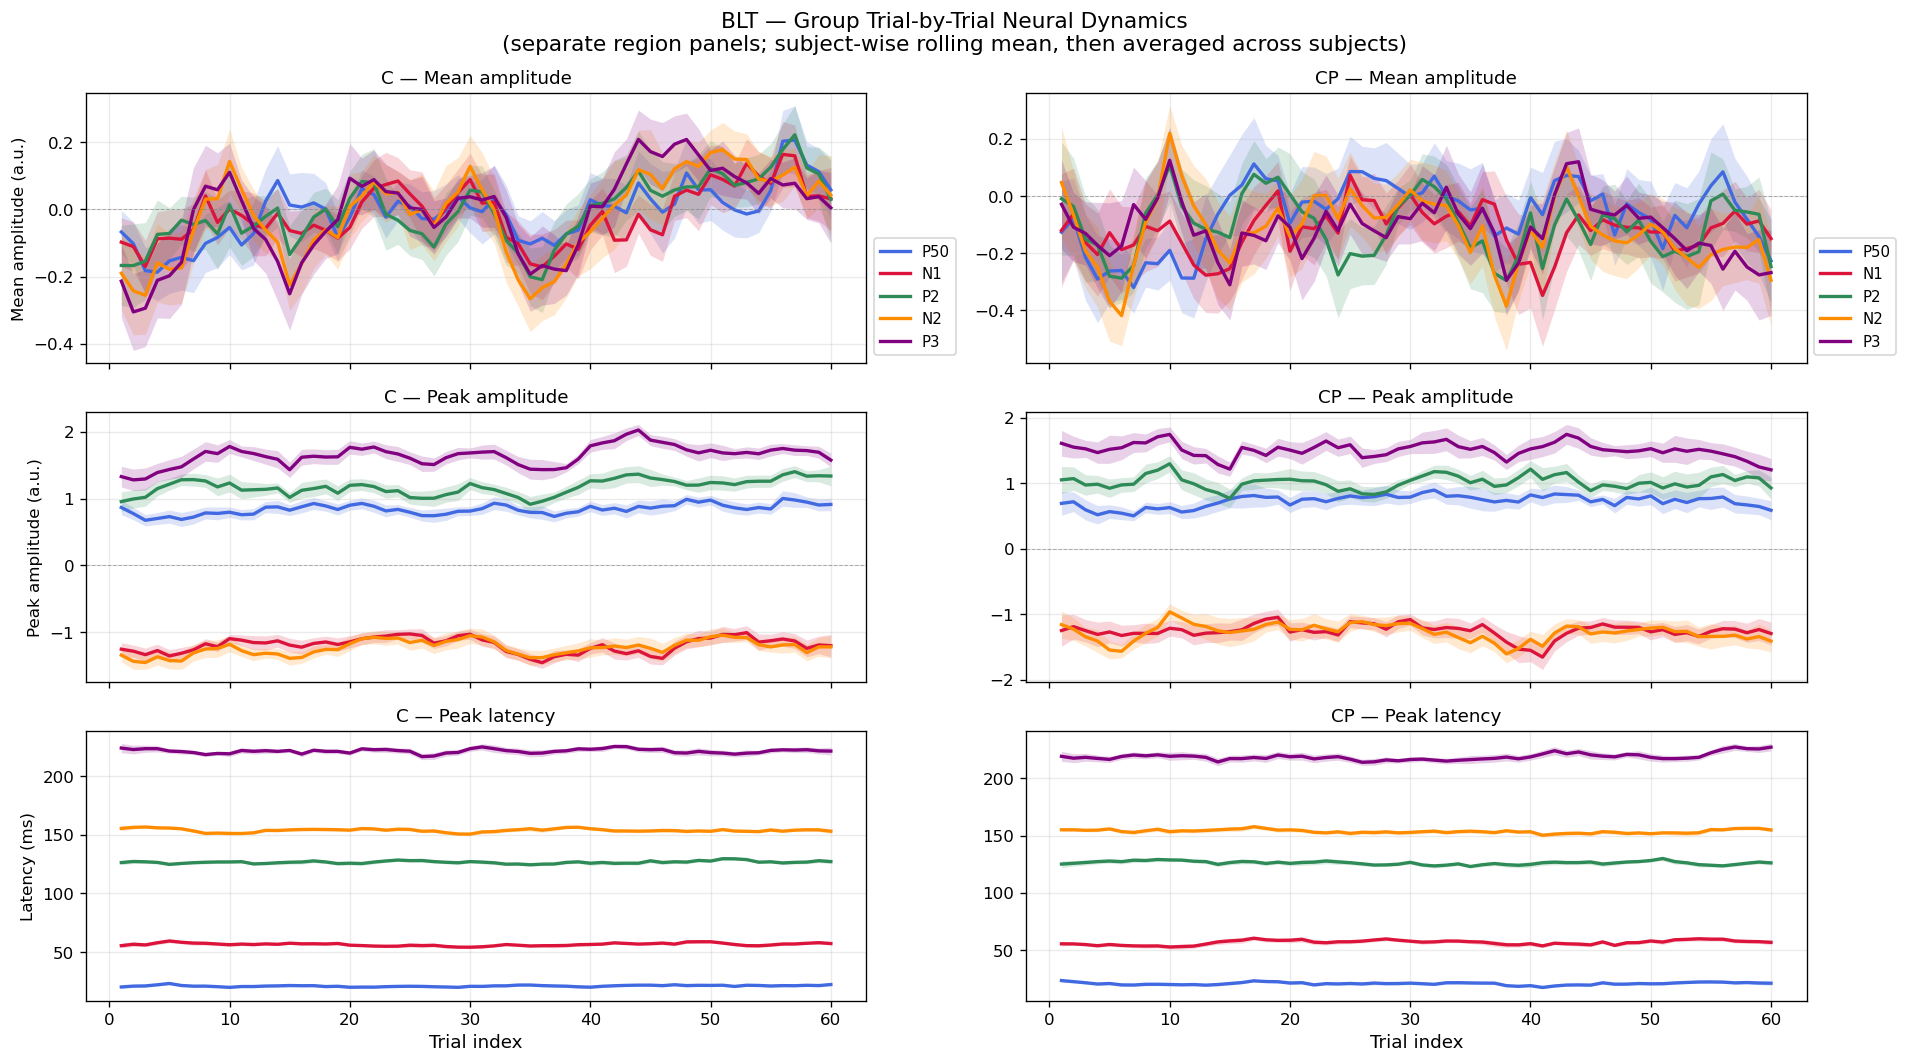

In [50]:
plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=True,
)

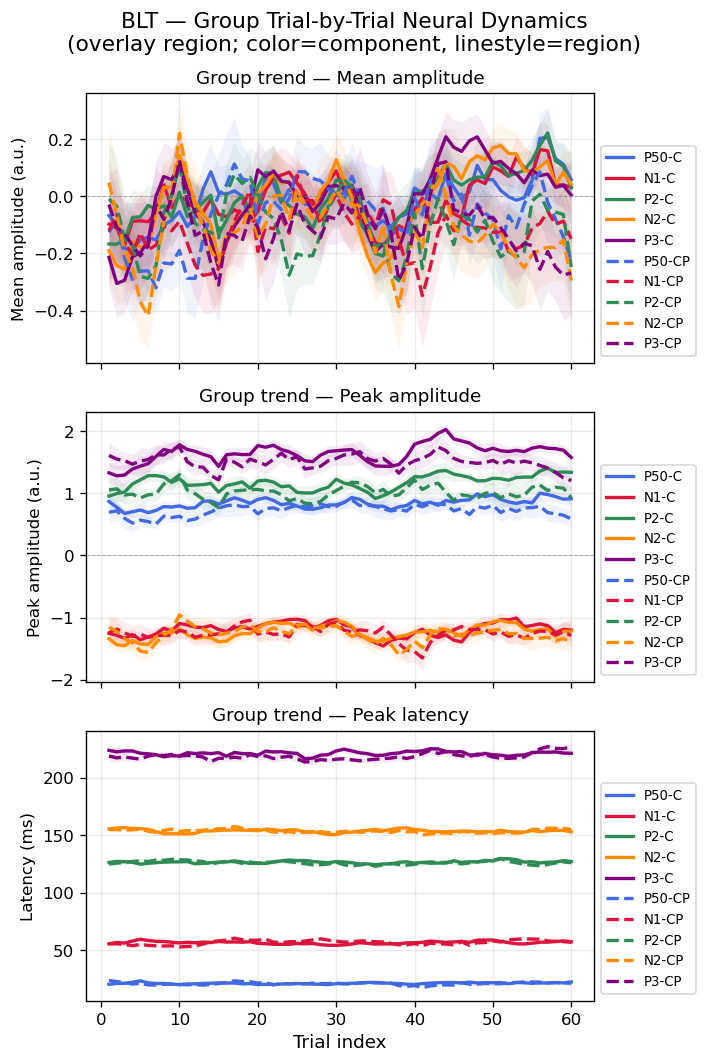

In [51]:
plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=False,
)

## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Feature windows | 0–100, 100–200, 200–400 ms (mean µV); 0–300 ms (peak µV + peak latency ms) |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)
